## Initialization

### Imports

In [3]:
from os import path
import warnings
assert path.exists("../solver") 
assert path.exists("../solver/utils")

In [2]:
%pip install -r requirements.txt

In [6]:
import sys
sys.path.append("..")

In [7]:
with warnings.catch_warnings():  # warning still somehow pierces through, so I cleared the cell output
    import tensorflow as tf  # tf 2.x
    import tensornetwork as tn
    tn.set_default_backend("tensorflow")
    
import numpy as np
import QGOpt as qgo
import math
import matplotlib.pyplot as plt

import solver.utils.general_utils as util
import solver.noising_tools as ns
import solver.utils.channel_utils as c_util
import solver.file_management as fm
import solver.circuits_generation as cg

from solver.QCCalc import QCEvaluator
from solver.experiments import ExperimentConductor, assert_psi2_eq_1
from solver.utils.misc import unwrap_dict, NconTemplate, INT, FLOAT, COMPLEX, ID_GATE
from solver.QCSolver import QGOptSolver, get_complex_channel_form, QGOptSolverDebug

### Quantum gates preparation

In [8]:
dim = 3

In [9]:
RX01 = tf.convert_to_tensor(np.array([[1/np.sqrt(2), -1j/np.sqrt(2), 0],
                 [-1j/np.sqrt(2), 1/np.sqrt(2), 0],
                 [0, 0, 1]]), dtype=COMPLEX)
RY01 = tf.convert_to_tensor(np.array([[1/np.sqrt(2), 1/np.sqrt(2), 0],
                 [-1/np.sqrt(2), 1/np.sqrt(2), 0],
                 [0, 0, 1]]), dtype=COMPLEX)

E = tf.eye(dim, dtype=COMPLEX)

In [10]:
def create_cx_qutrit():
    cx = np.zeros((9,9), dtype=complex)
    
    cx[0,0] = 1  # |00> → |00>
    cx[1,1] = 1  # |01> → |01>
    cx[2,2] = 1  # |02> → |02>
    
    cx[3,4] = 1  # |10> → |11>
    cx[4,5] = 1  # |11> → |12>
    cx[5,3] = 1  # |12> → |10>
    
    cx[6,6] = 1  # |20> → |22>
    cx[7,7] = 1  # |21> → |20>
    cx[8,8] = 1  # |22> → |21>
    
    return tf.constant(cx, dtype=COMPLEX)

In [11]:
CX = create_cx_qutrit()

In [13]:
Ry_channel = c_util.convert_1qmatrix_to_channel(RY01)
Rx_channel = c_util.convert_1qmatrix_to_channel(RX01)
E_channel = c_util.convert_1qmatrix_to_channel(E)
CX_channel = c_util.convert_2qmatrix_to_channel(util.convert_44_to_2222(CX, dim), dim)

Now we need to make set of channels from this. The recommended order is to fill all single-qubit gates, then internal identity gate (**this is important**), then all two-qubit gates.

In [14]:
default_pure_channels = {'Ry':Ry_channel,
                         'Rx':Rx_channel,
                         'M': E_channel,
                         ID_GATE:E_channel,
                         'CX': CX_channel
                        }                     

### Circuits preparation

In [15]:
NUM_QUBITS = 2

gates_labels = list(default_pure_channels.keys())
gates_labels.remove(ID_GATE)

gen = cg.DataGenerator(qubits_num=NUM_QUBITS,
                       gates_names=gates_labels,
                       single_qub_gates_num=3,
                       two_qub_gates_num=1)

In [17]:
def gen_circs_with_CX(enable_measurement: bool = True,
                      enable_CX: bool = True):
    preps_0 = [[],
               ['Rx_0'],
               ['Ry_0'],
               ['Rx_0', 'Rx_0']]
    preps_1 = [[],
               ['Rx_1'],
               ['Ry_1'],
               ['Rx_1', 'Rx_1']]
    
    toms = [[],
            ['Rx_0', 'Rx_1'],
            ['Ry_0', 'Ry_1']]
    
    meas_0 = [[],
              ['Rx_0'],
              ['Ry_0']]
    meas_1 = [[],
              ['Rx_1'],
              ['Ry_1']]
            
    if enable_measurement:
        for sublist in meas_0:
            sublist.append('M_0')
        for sublist in meas_1:
            sublist.append('M_1')
    
    ans = []
    tup_ans = []
    cx_array = ['CX_0_1'] if enable_CX else []
    
    if enable_CX:
        for prep_0 in preps_0:
            for prep_1 in preps_1:
                for m_0 in meas_0:
                    for m_1 in meas_1:
                        ans.append(prep_0 + prep_1 + ['CX_0_1'] + m_0 + m_1)
    else:
        for prep_0, prep_1 in zip(preps_0, preps_1):
            for m_0, m_1 in zip(meas_0, meas_1):
                for tom in toms:
                    ans.append(prep_0 + prep_1 + tom + m_0 + m_1)
                
    return ans

circs = gen_circs_with_CX(enable_measurement=True, enable_CX=True)

In [19]:
print(len(circs))

144


In [20]:
np.random.seed(101)
print(default_pure_channels.keys())

for idx in np.random.choice(np.arange(len(circs)), 4):
    print(f'Circuit #{idx} is represented as {circs[idx]}')

dict_keys(['Ry', 'Rx', 'M', '_E', 'CX'])
Circuit #95 is represented as ['Ry_0', 'Ry_1', 'CX_0_1', 'Rx_0', 'M_0', 'Ry_1', 'M_1']
Circuit #11 is represented as ['Rx_1', 'CX_0_1', 'M_0', 'Ry_1', 'M_1']
Circuit #81 is represented as ['Ry_0', 'Rx_1', 'CX_0_1', 'M_0', 'M_1']
Circuit #70 is represented as ['Rx_0', 'Rx_1', 'Rx_1', 'CX_0_1', 'Ry_0', 'M_0', 'Rx_1', 'M_1']


In [21]:
np.random.seed(1337)

ncon_tmpls = gen.get_tmpl_dict_from_human_circs(circs + [[]])  # add an empty circuit

#for idx in np.random.choice(np.arange(len(circs)), 3):
#    print(f'A quantum circuit with very simple "human" representation \n{circs[idx]}'
#    f'\nhas a very scary tensor network template \n{ncon_tmpls[str(idx)]}')

### Noising

The noise config may look quite complicated, but it's easier to grasp when you look closely at its element.
Element of a noise config is a tuple contaning
* label of a gate
* id of a gate; in a single-qubit case it coincides with qubit number and in two-qubit case it can be obtained by enumerating all qubit pairs. E. g. in three-qubit scenario, targer pairs `[(0, 1), (0, 2), (1, 0), (1, 2), (2, 0), (2, 1)]` will be mapped to ids from 0 to 5.
* function to noise - it's best to use a pre-defined function, which has four parameters
    * parameter for depolarization channel
    * parameter for amplitude damping
    * parameter for phase damping

In [22]:
noise_cfg = []

noise_cfg.append(('Ry', 0, ns.make_1q_4pars_channel, 0.02, 0.02, 0.02, dim))
noise_cfg.append(('Ry', 1, ns.make_1q_4pars_channel, 0.07, 0.03, 0.01, dim))

#noise_cfg.append(('Rx', 0, ns.make_1q_4pars_channel, 0.065, 0.02, 0.03, dim))
#noise_cfg.append(('Rx', 1, ns.make_1q_4pars_channel, 0.05, 0.045, 0.03, dim))

noise_cfg.append(('M', 0, ns.make_1q_4pars_channel, 0.04, 0.02, 0.025, dim))
noise_cfg.append(('M', 1, ns.make_1q_4pars_channel, 0.03, 0.03, 0.03, dim))

noise_cfg.append(('CX', 0, ns.make_2q_4pars_channel, 0.05, 0.02, 0.02, dim))

## Conducting experiment

We have a class called ExperimentConductor contaning all the parameters for our experiment. It has the:
* ideal gate set ${\bf G}^{\rm ideal}$
* noise configuration we have just made
* experiment name for working with files (more on that later)
* number of qubits
* learning rate
* regularization coefficients for one-qubit and two-qubit gates
* sample size a. k. a. shots number for sample generation (8192 is a realistic number you can get at real quantum PC)

Since we're not conducting any complicated experiments, the full functionality of this class will not be unleashed. However, it's convenient to store all the information together in order not to lose track. Notice the learning rate, regularizations and iterations hyperparameteres - they are all set here. These are not optimal but get the job done. Feel free to experiment!

In [23]:
with warnings.catch_warnings():
    exp_test = ExperimentConductor(pure_channels_set=default_pure_channels,
                                   noise_cfg=noise_cfg,
                                   exp_name='tomo_tutorial',
                                   qubits_num=NUM_QUBITS,
                                   lr=0.1,
                                   lmbd1=0.1,
                                   lmbd2=0.1,
                                   iterations=150,
                                   sample_size=8192)

First, let's use solver as a sample generator in order to generate the outcomes for each circuit. In the current version of the program, the number of outcomes (`sample_size`) is shared across all circuits.   
We are using the debug version of QGOptSolver since it gives more info. Pay attention to the variable `noise_iter0` - it determines the initial approximation. If you suspect your data to be noisy, increase it. It is **SUPER** important for convergence to set this above zero in order not to get stuck in a local minima! 

In [24]:
learnable_gates = {'Ry', 'M', 'CX'}

In [25]:
QC_t = QGOptSolverDebug(qudits_num=NUM_QUBITS,
                        single_qud_gates_names={'Ry', 'Rx', 'M'},
                        two_qud_gates_names={'CX'},
                        pure_channels_set=default_pure_channels,
                        learnable_gates_names = learnable_gates,
                        dim=dim,
                        compress_samples=True,
                        noise_params=exp_test.noise_params,
                        noise_iter0=0.05)

for name, tmpl in ncon_tmpls.items():
    QC_t.add_circuit(tn_template=tmpl, name=name)
    
QC_t.generate_all_samples(v=False, smpl_size=exp_test.sample_size)

Estimated set is generated from pure channels by applying noise parameters [0.05 0.   0.  ]
Learnable gates: {'CX', 'M', 'Ry'}
generating samples... 25% 50% 75% Done!


In [26]:
manif = qgo.manifolds.ChoiMatrix()
opt_t = qgo.optimizers.RAdam(manif, exp_test.lr)

We are ready to minimize the loss hard-coded in the solver:

In [28]:
loss_dynamics_t, norms_dict, _ = QC_t.train_optimizer(opt=opt_t,
                                                      lmbd1=exp_test.lmbd1,
                                                      lmbd2=exp_test.lmbd2,
                                                      iters=exp_test.iters,
                                                      v=1,
                                                      fid_ctr=20, # we'd like to calculate fidelities every 20 steps
                                                      norm_ctr=-1)  # we don't calculate L1 norms here

0 out of 150 iterations passed


KeyboardInterrupt: 

We can look at our loss dymamics to see that learning process was OK:

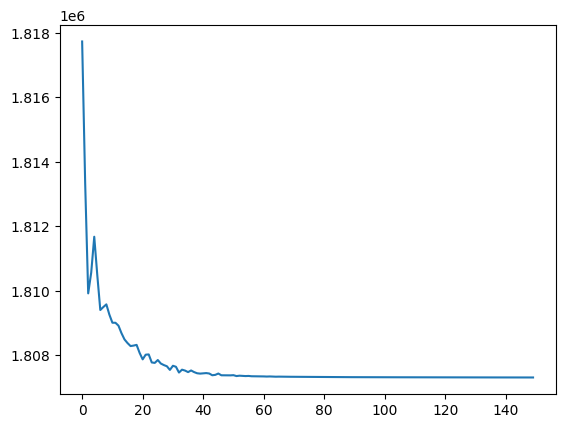

In [29]:
plt.plot(loss_dynamics_t)

## Results

The debug version of the solver has the ability to extract norms $\left( \| {\bf G}^{\rm est}(l,t) - {\bf G}^{\rm true}(l,t) \|, \; \| {\bf G}^{\rm est}(l,t) - {\bf G}^{\rm ideal}(l,t) \| \right) $ during each iteration of algorithm. These norms will provide us with beautiful graphs. For most of the gates, diamond norm in extracted, and for measurement gate ${\sf M}$ it is POVM norm (see article for details).  

Let's plot these norms vs. algorithm iteration number to prove that our algorithm did a good job. Remember, since we were the ones who generated the noise, we have information about norms between true vestions and estimated versions of quantum gates $\| {\bf G}^{\rm est}(l,t) - {\bf G}^{\rm true}(l,t) \| $. Of course, in real experiment we would be able to see only norms between ideal and estimated versions.

First, we extract the norms between true and ideal quantum gates; these norms will appear as horizontal lines a. k. a. answers. Our goal is to make ideal-estimated norm $\| {\bf G}^{\rm est}(l,t) - {\bf G}^{\rm ideal}(l,t) \| $ as close as possible to true-ideal norm $\| {\bf G}^{\rm true}(l,t) - {\bf G}^{\rm ideal}(l,t) \| $. This process is related to minimizing the true-estimated norm. Note that unlike in the article, here the number of circuis stays the same! X axis represents the number of iterations which is just a hyperparameter in the big experiment.

In [30]:
from collections import defaultdict
HLINES = defaultdict(list)

for label in QC_t.hidden_gates_dict:
    sublist = QC_t.hidden_gates_dict[label]
    for idx, gate in enumerate(sublist):
        if label == 'CX':
            HLINES[label].append(util.diamond_norm_2q(gate, default_pure_channels[label], dim))
        elif label == 'M':
            HLINES[label].append(util.get_povm_dist(gate, default_pure_channels[label], dim))
        else:
            HLINES[label].append(util.diamond_norm_1q(gate, default_pure_channels[label], dim))
            
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:gray']

### Plotting norms

In [31]:
def plot_diamond_norms(ax1, ax2):
    colors_idx = [0, 0]
    
    for key in norms_dict.keys():
        label, idx, norm_type = key

        if label in ['Rx', 'Ry', 'CX', 'X']:
            if label == 'CX' and idx == 1:
                continue
                
            if norm_type == 'i':
                ax1.plot(np.abs(norms_dict[label, idx, norm_type][0:]),
                         label=f'{label}{idx}',
                         color=COLORS[colors_idx[0]])
                ax1.axhline(y=HLINES[label][idx],
                            color=COLORS[colors_idx[0]],
                            linestyle=':')
                colors_idx[0] += 1

            else:
                ax2.plot(np.abs(norms_dict[label, idx, norm_type][0:]),
                         label=f'{label}{idx}',
                         color=COLORS[colors_idx[1]])
                ax1.axhline(y=HLINES[label][idx],
                            color=COLORS[colors_idx[1]],
                            linestyle=':')
                colors_idx[1] += 1
            
    ax1.set_title('Diamond norm(ideal, est)', {"size":18})
    ax1.set_xlabel('Algorithm iteration number', {"size":16})

    ax2.set_title('Diamond norm(true, est)', {"size":18})
    ax2.set_xlabel('Algorithm iteration number', {"size":16})

    ax1.legend(prop={'size': 14})
    ax2.legend(prop={'size': 14})
        
        # ax.set_ylim(0.92, 0.98)
        
def plot_povm_norms(ax1, ax2):
    colors_idx = [0, 0]
    
    for key in norms_dict.keys():
        label, idx, norm_type = key

        if label == 'M':
            if norm_type == 'i':
                ax1.plot(np.abs(norms_dict[label, idx, norm_type]),
                         label=f'{label}{idx}',
                         color=COLORS[colors_idx[0]])
                ax1.axhline(y=HLINES[label][idx],
                            color=COLORS[colors_idx[0]],
                            linestyle=':')
                colors_idx[0] += 1

            else:
                ax2.plot(np.abs(norms_dict[label, idx, norm_type]),
                         label=f'{label}{idx}',
                         color=COLORS[colors_idx[1]])
                colors_idx[1] += 1
            
    ax1.set_title('POVM norm(ideal, est)', {"size":18})
    ax1.set_xlabel('Algorithm iteration number', {"size":16})

    ax2.set_title('POVM norm(true, est)', {"size":18})
    ax2.set_xlabel('Algorithm iteration number', {"size":16})

    ax1.legend(prop={'size': 14})
    ax2.legend(prop={'size': 14})
        
        # ax.set_ylim(0.92, 0.98)

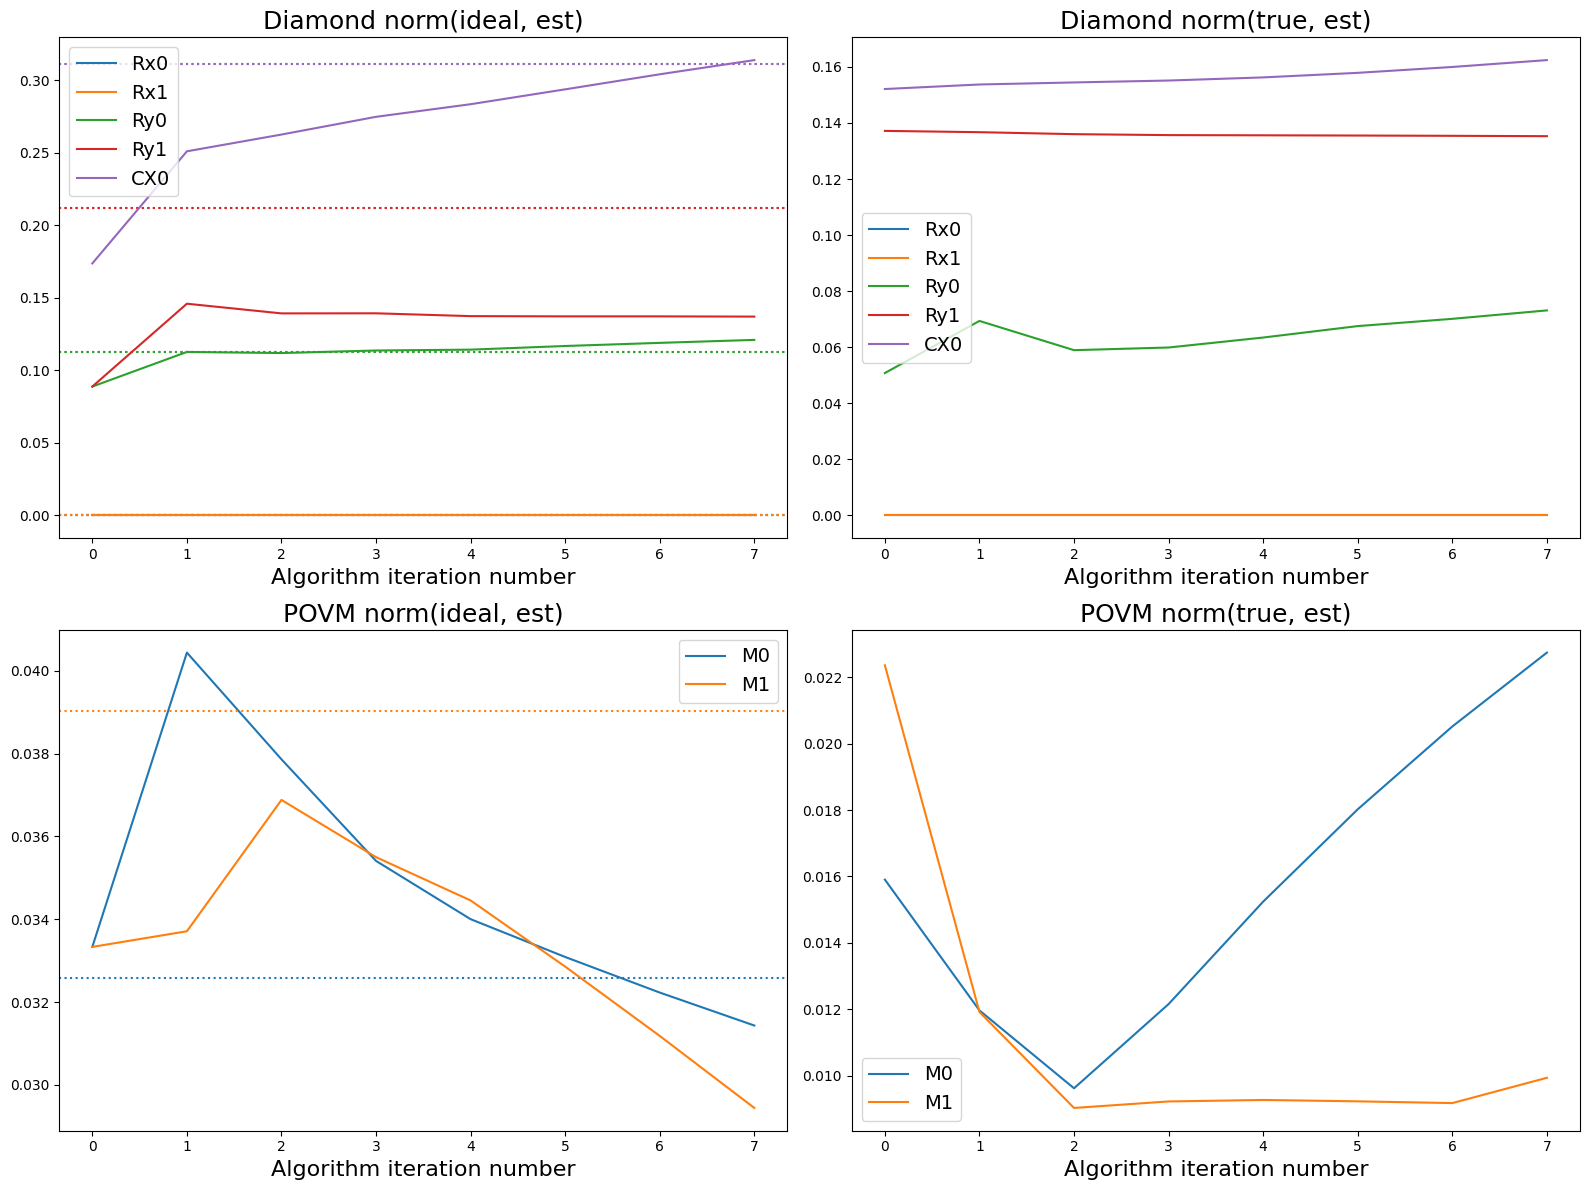

In [32]:
fig, axarr = plt.subplots(2, 2, figsize=(16, 12))
ax1, ax2, ax3, ax4 = [a for sublist in axarr for a in sublist]
plot_diamond_norms(ax1, ax2)
plot_povm_norms(ax3, ax4)
fig.tight_layout()
plt.show()